In [72]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [73]:
df = pd.read_csv("../data/investments_VC_new.csv")

In [74]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 6292 entries, 0 to 6291
Data columns (total 36 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   category_list         6063 non-null   str    
 1   market                6061 non-null   str    
 2   funding_total_usd     5374 non-null   float64
 3   status                6292 non-null   str    
 4   country_code          5665 non-null   str    
 5   state_code            4415 non-null   str    
 6   region                5665 non-null   str    
 7   city                  5602 non-null   str    
 8   funding_rounds        6292 non-null   int64  
 9   founded_at            4527 non-null   str    
 10  founded_month         4964 non-null   str    
 11  founded_quarter       4964 non-null   str    
 12  founded_year          4964 non-null   float64
 13  first_funding_at      6292 non-null   str    
 14  last_funding_at       6292 non-null   str    
 15  seed                  6292 non-n

In [75]:
heatmap_cols = [
    "funding_total_usd",
    "funding_rounds",
    "seed",
    "venture",
    "angel",
    "grant",
    "private_equity",
    "debt_financing",
    "convertible_note",
    "equity_crowdfunding",
]

round_heatmap_cols = [    
    "round_A",
    "round_B",
    "round_C",
    "round_D",
    "round_E",
    "round_F",
    "round_G",
    "round_H"
]



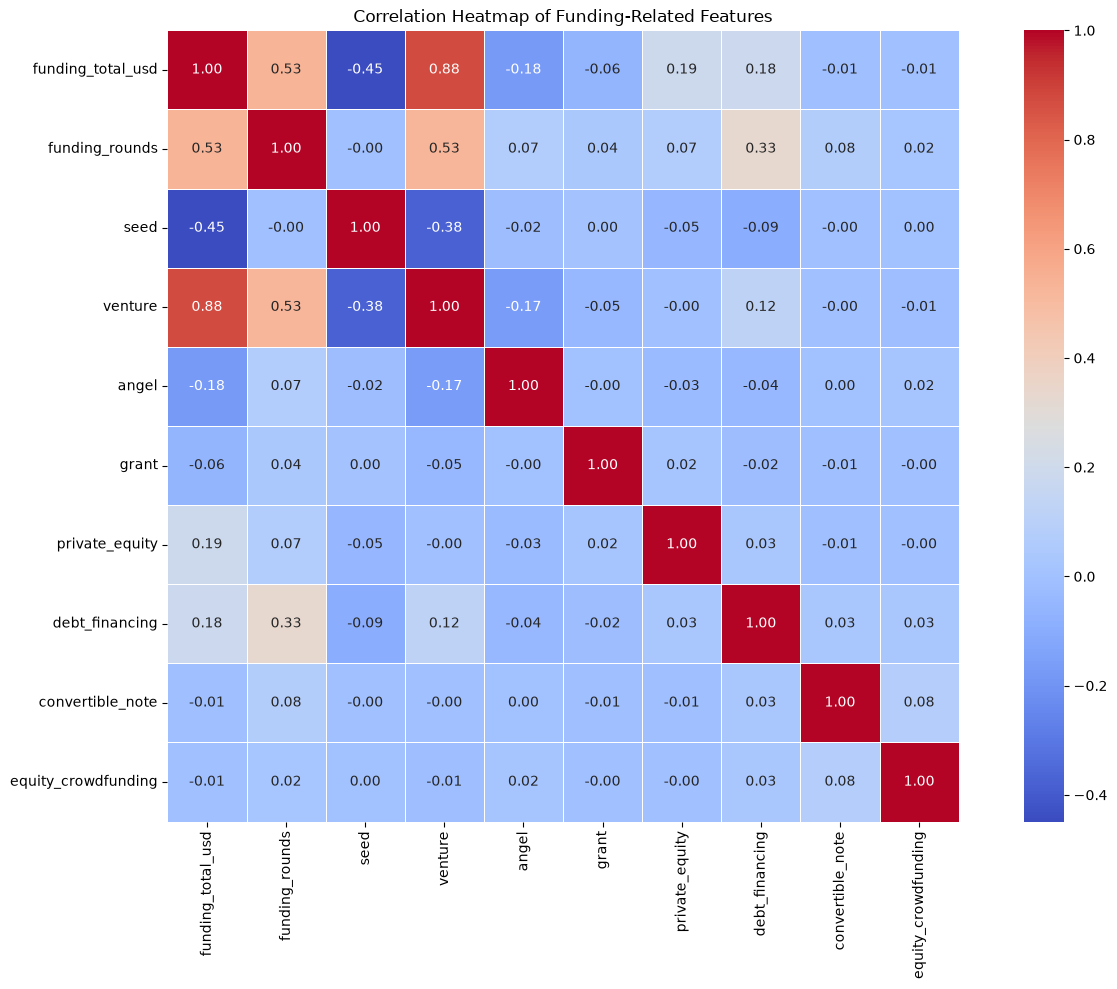

In [76]:
corr = df[heatmap_cols].corr(method="spearman")

plt.figure(figsize=(14, 10))

sns.heatmap(
    corr,
    cmap="coolwarm",
    annot=True,
    fmt=".2f",
    linewidths=0.5,
    square=True
)

plt.title("Correlation Heatmap of Funding-Related Features")

plt.tight_layout()

plt.show()

In [77]:
date_cols = [
    'founded_at',
    'first_funding_at',
    'last_funding_at'
]

for col in date_cols:
    df[col] = pd.to_datetime(df[col], errors='coerce')

In [78]:
df["days_to_first_funding"] = (
    df["first_funding_at"] - df["founded_at"]
).dt.days

In [79]:
df["days_to_first_funding"].describe()

count     4527.000000
mean      1291.682571
std       2068.482642
min      -2922.000000
25%        213.000000
50%        605.000000
75%       1637.000000
max      37466.000000
Name: days_to_first_funding, dtype: float64

In [80]:
df["funding_duration_days"] = (
    df["last_funding_at"] - df["first_funding_at"]
).dt.days

In [81]:
df["funding_duration_days"].describe()

count     6292.000000
mean       367.953115
std        672.580233
min          0.000000
25%          0.000000
50%          0.000000
75%        552.250000
max      17287.000000
Name: funding_duration_days, dtype: float64

In [82]:
df["avg_funding_per_round"] = (
    df["funding_total_usd"] / df["funding_rounds"]
)

In [83]:
df["avg_funding_per_round"] = np.where(
    df["funding_rounds"] > 0,
    df["funding_total_usd"] / df["funding_rounds"],
    np.nan
)

In [84]:
df["avg_funding_per_round"].describe()

count    5.374000e+03
mean     8.388172e+06
std      3.414841e+07
min      1.000000e+03
25%      6.000000e+05
50%      3.000000e+06
75%      8.000000e+06
max      1.425000e+09
Name: avg_funding_per_round, dtype: float64

In [85]:
df["log_funding_total_usd"] = np.log1p(df["funding_total_usd"])

In [86]:
df["log_funding_total_usd"].describe()

count    5374.000000
mean       14.935001
std         2.228442
min         6.908755
25%        13.644440
50%        15.319588
75%        16.556351
max        22.463732
Name: log_funding_total_usd, dtype: float64

In [87]:
df["category_list"].str.split("|").str.len().value_counts().sort_index()

category_list
3.0     3304
4.0      809
5.0      734
6.0      511
7.0      289
8.0      188
9.0      106
10.0      61
11.0      29
12.0      14
13.0       9
14.0       2
15.0       4
16.0       2
17.0       1
Name: count, dtype: int64

In [88]:
markets = sorted(df["market"].dropna().unique())

print(markets)

[' 3D ', ' Accounting ', ' Ad Targeting ', ' Advertising ', ' Advertising Platforms ', ' Advice ', ' Aerospace ', ' Agriculture ', ' All Markets ', ' All Students ', ' Analytics ', ' Android ', ' App Marketing ', ' Application Platforms ', ' Apps ', ' Architecture ', ' Archiving ', ' Art ', ' Artificial Intelligence ', ' Artists Globally ', ' Auctions ', ' Audio ', ' Auto ', ' Automotive ', ' B2B ', ' Babies ', ' Banking ', ' Beauty ', ' Big Data ', ' Big Data Analytics ', ' Billing ', ' Bioinformatics ', ' Biotechnology ', ' Blogging Platforms ', ' Brand Marketing ', ' Browser Extensions ', ' Business Development ', ' Business Intelligence ', ' Business Services ', ' CRM ', ' Cable ', ' Career Management ', ' Career Planning ', ' Cars ', ' Celebrity ', ' Charity ', ' Chat ', ' Classifieds ', ' Clean Energy ', ' Clean Technology ', ' Clinical Trials ', ' Cloud Computing ', ' Cloud Data Services ', ' Cloud Infrastructure ', ' Cloud Management ', ' Cloud Security ', ' Collaboration ', ' 

In [89]:
df["market"] = df["market"].str.strip()

In [90]:
df["market"].value_counts().head(30)

market
Software                718
Curated Web             459
Mobile                  342
Biotechnology           322
Enterprise Software     249
Games                   227
Advertising             214
E-Commerce              187
Social Media            162
Clean Technology        138
Hardware + Software     137
Semiconductors          127
Health Care             118
Web Hosting             115
Security                115
Finance                  97
Messaging                73
Analytics                71
Search                   61
Music                    60
Public Relations         59
Education                53
News                     52
Health and Wellness      52
Video                    47
Travel                   46
Consulting               45
Networking               42
Social Network Media     41
Photography              37
Name: count, dtype: int64

In [91]:
# Remove leading/trailing spaces
df["market"] = df["market"].str.strip()

def map_market_sector(market):
    if pd.isna(market):
        return "Other"

    market = market.lower()

    # ------------------------------------------------------------------
    # Software & Cloud
    # ------------------------------------------------------------------
    if any(k in market for k in [
        "software", "saas", "cloud", "web",
        "developer", "api", "database",
        "hosting", "development platform",
        "apps", "storage", "technology",
        "paas", "iaas", "cloud management",
        "cloud infrastructure",
        "cloud data services"
    ]):
        return "Software & Cloud"

    # ------------------------------------------------------------------
    # AI & Data
    # ------------------------------------------------------------------
    elif any(k in market for k in [
        "artificial intelligence",
        "machine learning",
        "analytics",
        "big data",
        "data mining",
        "predictive",
        "visualization",
        "data integration",
        "bioinformatics",
        "image recognition",
        "speech recognition",
        "natural language",
        "business intelligence"
    ]):
        return "AI & Data"

    # ------------------------------------------------------------------
    # Healthcare & Biotech
    # ------------------------------------------------------------------
    elif any(k in market for k in [
        "health",
        "medical",
        "biotechnology",
        "diagnostic",
        "clinical",
        "pharmaceutical",
        "hospital",
        "doctor",
        "physician",
        "healthcare",
        "life sciences",
        "medical devices",
        "diabetes"
    ]):
        return "Healthcare & Biotech"

    # ------------------------------------------------------------------
    # Financial Services
    # ------------------------------------------------------------------
    elif any(k in market for k in [
        "finance",
        "financial",
        "bank",
        "payment",
        "credit",
        "investment",
        "venture capital",
        "stock",
        "trading"
    ]):
        return "Financial Services"

    # ------------------------------------------------------------------
    # E-commerce & Retail
    # ------------------------------------------------------------------
    elif any(k in market for k in [
        "e-commerce",
        "shopping",
        "retail",
        "marketplace",
        "coupon",
        "flash sales",
        "consumer goods",
        "reviews and recommendations"
    ]):
        return "E-commerce & Retail"

    # ------------------------------------------------------------------
    # Media & Entertainment
    # ------------------------------------------------------------------
    elif any(k in market for k in [
        "media",
        "music",
        "video",
        "game",
        "gaming",
        "television",
        "film",
        "photography",
        "digital media",
        "news",
        "entertainment",
        "sports",
        "publishing",
        "content",
        "audio",
        "photo sharing"
    ]):
        return "Media & Entertainment"

    # ------------------------------------------------------------------
    # Mobile & Telecom
    # ------------------------------------------------------------------
    elif any(k in market for k in [
        "mobile",
        "telecommunication",
        "voip",
        "sms",
        "iphone",
        "ipad",
        "ios",
        "android",
        "wireless"
    ]):
        return "Mobile & Telecom"

    # ------------------------------------------------------------------
    # Education
    # ------------------------------------------------------------------
    elif any(k in market for k in [
        "education",
        "school",
        "college",
        "university",
        "learning",
        "tutoring",
        "student"
    ]):
        return "Education"

    # ------------------------------------------------------------------
    # Travel & Hospitality
    # ------------------------------------------------------------------
    elif any(k in market for k in [
        "travel",
        "tourism",
        "hotel",
        "restaurant",
        "vacation",
        "hospitality"
    ]):
        return "Travel & Hospitality"

    # ------------------------------------------------------------------
    # Energy & Environment
    # ------------------------------------------------------------------
    elif any(k in market for k in [
        "energy",
        "solar",
        "renewable",
        "clean",
        "environment",
        "sustainability"
    ]):
        return "Energy & Environment"

    # ------------------------------------------------------------------
    # Security
    # ------------------------------------------------------------------
    elif any(k in market for k in [
        "security",
        "cyber",
        "privacy",
        "fraud"
    ]):
        return "Security"

    # ------------------------------------------------------------------
    # Manufacturing & Industrial
    # ------------------------------------------------------------------
    elif any(k in market for k in [
        "manufacturing",
        "industrial",
        "robotics",
        "hardware",
        "semiconductor",
        "electronics",
        "automation",
        "nanotechnology"
    ]):
        return "Manufacturing & Industrial"

    # ------------------------------------------------------------------
    # Transportation & Automotive
    # ------------------------------------------------------------------
    elif any(k in market for k in [
        "transport",
        "automotive",
        "taxi",
        "car",
        "gps",
        "navigation",
        "shipping",
        "location based services",
        "maps",
        "tracking"
    ]):
        return "Transportation & Automotive"

    # ------------------------------------------------------------------
    # Real Estate
    # ------------------------------------------------------------------
    elif any(k in market for k in [
        "real estate",
        "property",
        "housing"
    ]):
        return "Real Estate"

    # ------------------------------------------------------------------
    # Social & Community
    # ------------------------------------------------------------------
    elif any(k in market for k in [
        "social",
        "community",
        "network",
        "blog",
        "forum",
        "messaging",
        "chat",
        "facebook",
        "twitter",
        "nonprofits"
    ]):
        return "Social & Community"

    # ------------------------------------------------------------------
    # Consumer & Lifestyle
    # ------------------------------------------------------------------
    elif any(k in market for k in [
        "fashion",
        "beauty",
        "fitness",
        "lifestyle",
        "food",
        "wine",
        "consumer",
        "home",
        "baby",
        "pet",
        "design"
    ]):
        return "Consumer & Lifestyle"

    # ------------------------------------------------------------------
    # Advertising & Marketing
    # ------------------------------------------------------------------
    elif any(k in market for k in [
        "advertising",
        "advertising platforms",
        "ad targeting",
        "brand marketing",
        "marketing",
        "search marketing",
        "email marketing",
        "internet marketing",
        "public relations",
        "sales and marketing",
        "mobile advertising"
    ]):
        return "Advertising & Marketing"

    # ------------------------------------------------------------------
    # Business Services
    # ------------------------------------------------------------------
    elif any(k in market for k in [
        "business services",
        "business development",
        "consulting",
        "customer service",
        "customer support",
        "recruiting",
        "legal",
        "crm",
        "enterprises",
        "startup",
        "services",
        "professional services"
    ]):
        return "Business Services"

    # ------------------------------------------------------------------
    # Internet & Web
    # ------------------------------------------------------------------
    elif any(k in market for k in [
        "internet",
        "search",
        "email",
        "browser extensions",
        "local",
        "portal"
    ]):
        return "Internet & Web"

    else:
        return "Other"


# Create new feature
df["market_sector"] = df["market"].apply(map_market_sector)

In [92]:
df['market_sector'].value_counts()

market_sector
Software & Cloud               2367
Media & Entertainment           796
Other                           531
Mobile & Telecom                437
Advertising & Marketing         327
E-commerce & Retail             261
Healthcare & Biotech            247
Social & Community              202
Manufacturing & Industrial      192
Financial Services              135
Business Services               132
Security                        131
Internet & Web                  125
AI & Data                       106
Transportation & Automotive      86
Education                        64
Travel & Hospitality             60
Consumer & Lifestyle             59
Real Estate                      18
Energy & Environment             16
Name: count, dtype: int64

In [93]:
(df["market_sector"].value_counts(normalize=True) * 100).round(2)

market_sector
Software & Cloud               37.62
Media & Entertainment          12.65
Other                           8.44
Mobile & Telecom                6.95
Advertising & Marketing         5.20
E-commerce & Retail             4.15
Healthcare & Biotech            3.93
Social & Community              3.21
Manufacturing & Industrial      3.05
Financial Services              2.15
Business Services               2.10
Security                        2.08
Internet & Web                  1.99
AI & Data                       1.68
Transportation & Automotive     1.37
Education                       1.02
Travel & Hospitality            0.95
Consumer & Lifestyle            0.94
Real Estate                     0.29
Energy & Environment            0.25
Name: proportion, dtype: float64

In [94]:
round_cols = [
    "round_A","round_B","round_C","round_D",
    "round_E","round_F","round_G","round_H"
]
((df[round_cols] > 0).mean() * 100).round(2)

round_A    26.56
round_B    19.10
round_C    10.89
round_D     4.91
round_E     1.81
round_F     0.51
round_G     0.06
round_H     0.00
dtype: float64

In [95]:
df[["round_A", "round_B", "round_C", "round_D"]].head(10)

,round_A,round_B,round_C,round_D
0,0,0,0,0
1,0,0,0,0
2,0,0,0,0
3,2520000,0,0,0
4,0,0,0,0
5,0,0,0,0
6,0,0,0,0
7,14000000,0,0,0
8,0,0,0,0
9,0,0,0,0


In [96]:
selected_features = [
    # Numerical
    "funding_total_usd",
    "funding_rounds",
    "funding_duration_days",
    "avg_funding_per_round",

    # Categorical
    "market_sector",

    # Funding Types
    "seed",
    "venture",
    "equity_crowdfunding",
    "undisclosed",
    "convertible_note",
    "debt_financing",
    "angel",
    "grant",
    "private_equity",
    "product_crowdfunding",

    # Target
    "status"
]

model_df = df[selected_features].copy()

In [97]:
model_df.isnull().sum()

funding_total_usd        918
funding_rounds             0
funding_duration_days      0
avg_funding_per_round    918
market_sector              0
seed                       0
venture                    0
equity_crowdfunding        0
undisclosed                0
convertible_note           0
debt_financing             0
angel                      0
grant                      0
private_equity             0
product_crowdfunding       0
status                     0
dtype: int64

In [98]:
median_funding = model_df["funding_total_usd"].median()

model_df["funding_total_usd"] = model_df["funding_total_usd"].fillna(
    median_funding
)

In [99]:
model_df["avg_funding_per_round"] = (
    model_df["funding_total_usd"] /
    model_df["funding_rounds"]
)

In [100]:
model_df.isnull().sum()

funding_total_usd        0
funding_rounds           0
funding_duration_days    0
avg_funding_per_round    0
market_sector            0
seed                     0
venture                  0
equity_crowdfunding      0
undisclosed              0
convertible_note         0
debt_financing           0
angel                    0
grant                    0
private_equity           0
product_crowdfunding     0
status                   0
dtype: int64

In [ ]:
model_df.to_csv("../data/model_df.csv", index=False)

: 